# Regresion lineal vs. clasificacion

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# Cargar los datos


In [66]:
datos = pd.read_csv("winequality-red.csv", sep=";")
print(datos.shape)
datos.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 1. Regresion
Predecimos `quality` con regresión lineal y comparamos a como se comporta con predecir siempre el promedio.

In [67]:
X = datos.drop(columns="quality")
y = datos["quality"]

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Entrenamiento:", X_entrenamiento.shape)
print("Prueba:", X_prueba.shape)

Entrenamiento: (1279, 11)
Prueba: (320, 11)


In [68]:
modelo_regresion = LinearRegression()
modelo_regresion.fit(X_entrenamiento, y_entrenamiento)

y_predicho = modelo_regresion.predict(X_prueba)
rmse_modelo = np.sqrt(mean_squared_error(y_prueba, y_predicho))

r2_modelo = r2_score(y_prueba, y_predicho)
promedio_entrenamiento = y_entrenamiento.mean()
y_promedio = np.full(len(y_prueba), promedio_entrenamiento)

rmse_promedio = np.sqrt(mean_squared_error(y_prueba, y_promedio))
r2_promedio = r2_score(y_prueba, y_promedio)

print("Promedio de quality en entrenamiento:", round(promedio_entrenamiento, 4))
print()
print("Regresión lineal RMSE:", round(rmse_modelo, 4), " R2:", round(r2_modelo, 4))
print("Siempre promedio RMSE:", round(rmse_promedio, 4), " R2:", round(r2_promedio, 4))

Promedio de quality en entrenamiento: 5.6239

Regresión lineal RMSE: 0.6245  R2: 0.4032
Siempre promedio RMSE: 0.8107  R2: -0.0056


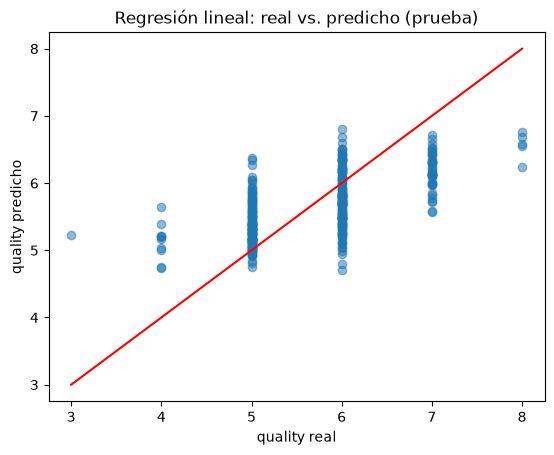

In [69]:
plt.scatter(y_prueba, y_predicho, alpha=0.5)
plt.plot([3, 8], [3, 8], color="red")
plt.xlabel("quality real")
plt.ylabel("quality predicho")
plt.title("Regresión lineal: real vs. predicho (prueba)")
plt.show()

La regresion baja el RMSE y tiene un R² positivo, predecir el promedio tiene R² aproximadamente igual a 0 (no explica nada de la variación). Asi que la recta si aporta informacion, aunque no es perfecta.

# 2. Clasificacion con la misma regresion
Definimos *bueno* = `quality >= 7`, ajustamos la regresión lineal a esa columna (0 ó 1) y clasificamos como bueno si y_gorro ≥ 0.5.

In [70]:
datos["bueno"] = (datos["quality"] >= 7).astype(int)
print(datos["bueno"].value_counts())
print("Proporción de buenos:", round(datos["bueno"].mean(), 4))
y_bueno = datos["bueno"]

X_entrenamiento, X_prueba, y_bueno_entrenamiento, y_bueno_prueba = train_test_split(
    X, y_bueno, test_size=0.2, random_state=42)

modelo_clasificacion = LinearRegression()
modelo_clasificacion.fit(X_entrenamiento, y_bueno_entrenamiento)

y_gorro = modelo_clasificacion.predict(X_prueba)
clase_predicha = (y_gorro >= 0.5).astype(int)

bueno
0    1382
1     217
Name: count, dtype: int64
Proporción de buenos: 0.1357


In [71]:
aciertos_modelo = accuracy_score(y_bueno_prueba, clase_predicha)

siempre_no_bueno = np.zeros(len(y_bueno_prueba))
aciertos_base = accuracy_score(y_bueno_prueba, siempre_no_bueno)

menores_que_cero = (y_gorro < 0).sum()
mayores_que_uno = (y_gorro > 1).sum()
fuera_de_rango = menores_que_cero + mayores_que_uno

print("Aciertos de la recta como clasificador:", round(aciertos_modelo * 100, 2), "%")
print("Aciertos de predecir siempre 'no bueno':", round(aciertos_base * 100, 2), "%")
print()
print("y_gorro menores que 0:", menores_que_cero)
print("y_gorro mayores que 1:", mayores_que_uno)
print("y_gorro fuera de [0, 1] en total:", fuera_de_rango, "de", len(y_gorro))
print("y_gorro mínimo:", round(y_gorro.min(), 4), " y_gorro máximo:", round(y_gorro.max(), 4))

Aciertos de la recta como clasificador: 86.25 %
Aciertos de predecir siempre 'no bueno': 85.31 %

y_gorro menores que 0: 82
y_gorro mayores que 1: 0
y_gorro fuera de [0, 1] en total: 82 de 320
y_gorro mínimo: -0.1504  y_gorro máximo: 0.5439


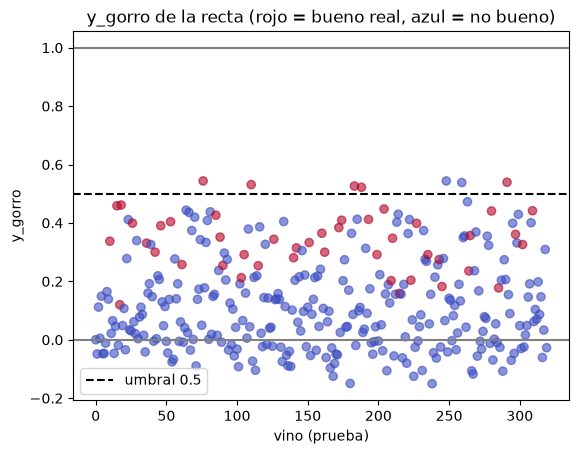

In [72]:
plt.scatter(range(len(y_gorro)), y_gorro, c=y_bueno_prueba, cmap="coolwarm", alpha=0.6)
plt.axhline(0.5, color="black", linestyle="--", label="umbral 0.5")
plt.axhline(0, color="gray")
plt.axhline(1, color="gray")
plt.xlabel("vino (prueba)")
plt.ylabel("y_gorro")
plt.title("y_gorro de la recta (rojo = bueno real, azul = no bueno)")
plt.legend()
plt.show()

# Conclusion

Entre los dos problemas cambia lo que se predice, en regresión `quality` es un número (3 a 8) y el error se mide en las mismas unidades (RMSE), por lo que la recta mejora claramente al promedio (RMSE ≈ 0.62 contra 0.81 y R² ≈ 0.40 contra ≈ 0) en clasificación la variable es 0 ó 1, está desbalanceada (solo 14 % son buenos) y lo que importa es acertar la clase. Ahí la recta saca aproximadamente 86.25 % de aciertos, pero predecir siempre "no bueno" ya da ≈ 85.31 %, así que casi no mejora a la base. Además, a la recta falla ya que no está hecha para clasificar, su y_gorro no está acotada, no es una probabilidad (82 valores quedaron por debajo de 0 y ninguno pasó de 1), minimiza el error cuadrático y no el error de clasificación, y el umbral de 0.5 queda lejos de casi todos los y_gorro porque la clase buena es rara (el y_gorro máximo es aproximadamente 0.54), por lo que casi nunca detecta vinos buenos. Para clasificar conviene algun otro modelo que nos permita obtener una mejor regresesión.

# Referencias

Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Wine Quality [Conjunto de datos]. UCI Machine Learning Repository. https://doi.org/10.24432/C56S3T

# Declaracion de uso de la IA

Para esta practica se utilizo la inteligencia artificial Anthropic Claude como herramienta de asistencia para la revision, edicion y mejora del formato de texto asi como el apoyo en la toma de sugerencias para la parte del codigo y la correccion de errores.